In [1]:
using ShipMMG
# u.-sing Plots, StatsPlots
using Turing, DifferentialEquations, ForwardDiff, Bijectors, DomainSets
using CSV, Random, DataFrames, Distributions, StatsBase
using ProgressMeter
using LinearAlgebra
using PyPlot, LaTeXStrings, PyCall
@pyimport numpy as np
@pyimport scienceplots

using Pkg
Pkg.status("ShipMMG")

Project ShipMMG v0.0.8
No Matches in `~/Documents/M1/ShipMMG.jl/Project.toml`


In [2]:
basic_params = get_KCS_basic_params()
maneuvering_params = get_KCS_maneuvering_params()
wind_coef_prams = get_example_ship_wind_force_moment_params()
L_pp = basic_params.L_pp
B = basic_params.B
d = basic_params.d

0.143

In [3]:
δ = 35 #deg
duration = 100
noise = "B"
wind = 0

num1 = 1
num2 = 4000
# num1 = 3501
# num2 = 3600

4000

In [4]:
n_const = 15  # [rps]

sampling = duration * 10
time_list = range(0.00, stop=duration, length=sampling)
δ_rad_list = δ .* pi / 180.0  .* ones(Float64, sampling)
# δ_rad_list = δ .* sin.(time_list./(100/6pi)) .* pi / 180.0
n_p_list = n_const .* ones(Float64, sampling)
U_W_list = wind .* ones(Float64, sampling) ./5
ψ_W_list = deg2rad.(0 .* ones(Float64, sampling))


mmg_results = mmg_3dof_simulate(
    basic_params,
    maneuvering_params,
    wind_coef_prams,
    time_list,
    δ_rad_list,
    n_p_list,
    U_W_list,
    ψ_W_list,
    u0=1.25,
    v0=0.0,
    r0=0.0,
)
u, v, r, x, y, ψ, δ, n_p = mmg_results

p = CSV.read("data/30sint_B_s2.csv", DataFrame)

struct SimulationResults
    data::Dict{Int, DataFrame}
end

results = SimulationResults(Dict{Int, DataFrame}())

k_0 = maneuvering_params.k_0
k_1 = maneuvering_params.k_1
k_2 = maneuvering_params.k_2

for i in num1:num2
    R_0_dash = p[i, 4]
    X_vv_dash = p[i, 5]
    X_vr_dash = p[i, 6]
    X_rr_dash = p[i, 7]
    X_vvvv_dash = p[i, 8]
    Y_v_dash = p[i, 9]
    Y_r_dash = p[i, 10]
    Y_vvv_dash = p[i, 11]
    Y_vvr_dash = p[i, 12]
    Y_vrr_dash = p[i, 13]
    Y_rrr_dash = p[i, 14]
    N_v_dash = p[i, 15]
    N_r_dash = p[i, 16]
    N_vvv_dash = p[i, 17]
    N_vvr_dash = p[i, 18]
    N_vrr_dash = p[i, 19]
    N_rrr_dash = p[i, 20]

    maneuvering_params = Mmg3DofManeuveringParams(
        k_0,
        k_1,
        k_2,
        R_0_dash,
        X_vv_dash,
        X_vr_dash,
        X_rr_dash,
        X_vvvv_dash,
        Y_v_dash,
        Y_r_dash,
        Y_vvv_dash,
        Y_vvr_dash,
        Y_vrr_dash,
        Y_rrr_dash,
        N_v_dash,
        N_r_dash,
        N_vvv_dash,
        N_vvr_dash,
        N_vrr_dash,
        N_rrr_dash,
    )

    mmg_results = mmg_3dof_simulate(
        basic_params,
        maneuvering_params,
        wind_coef_prams,
        time_list,
        δ_rad_list,
        n_p_list,
        U_W_list,
        ψ_W_list,
        u0=1.25,
        v0=0.0,
        r0=0.0,
    )

    mmg_results_df = DataFrame(
    u = mmg_results[1],
    v = mmg_results[2],
    r = mmg_results[3],
    x = mmg_results[4],
    y = mmg_results[5],
    ψ = mmg_results[6],
    δ = mmg_results[7],
    n_p = mmg_results[8],
    )

    results.data[i] = mmg_results_df
end

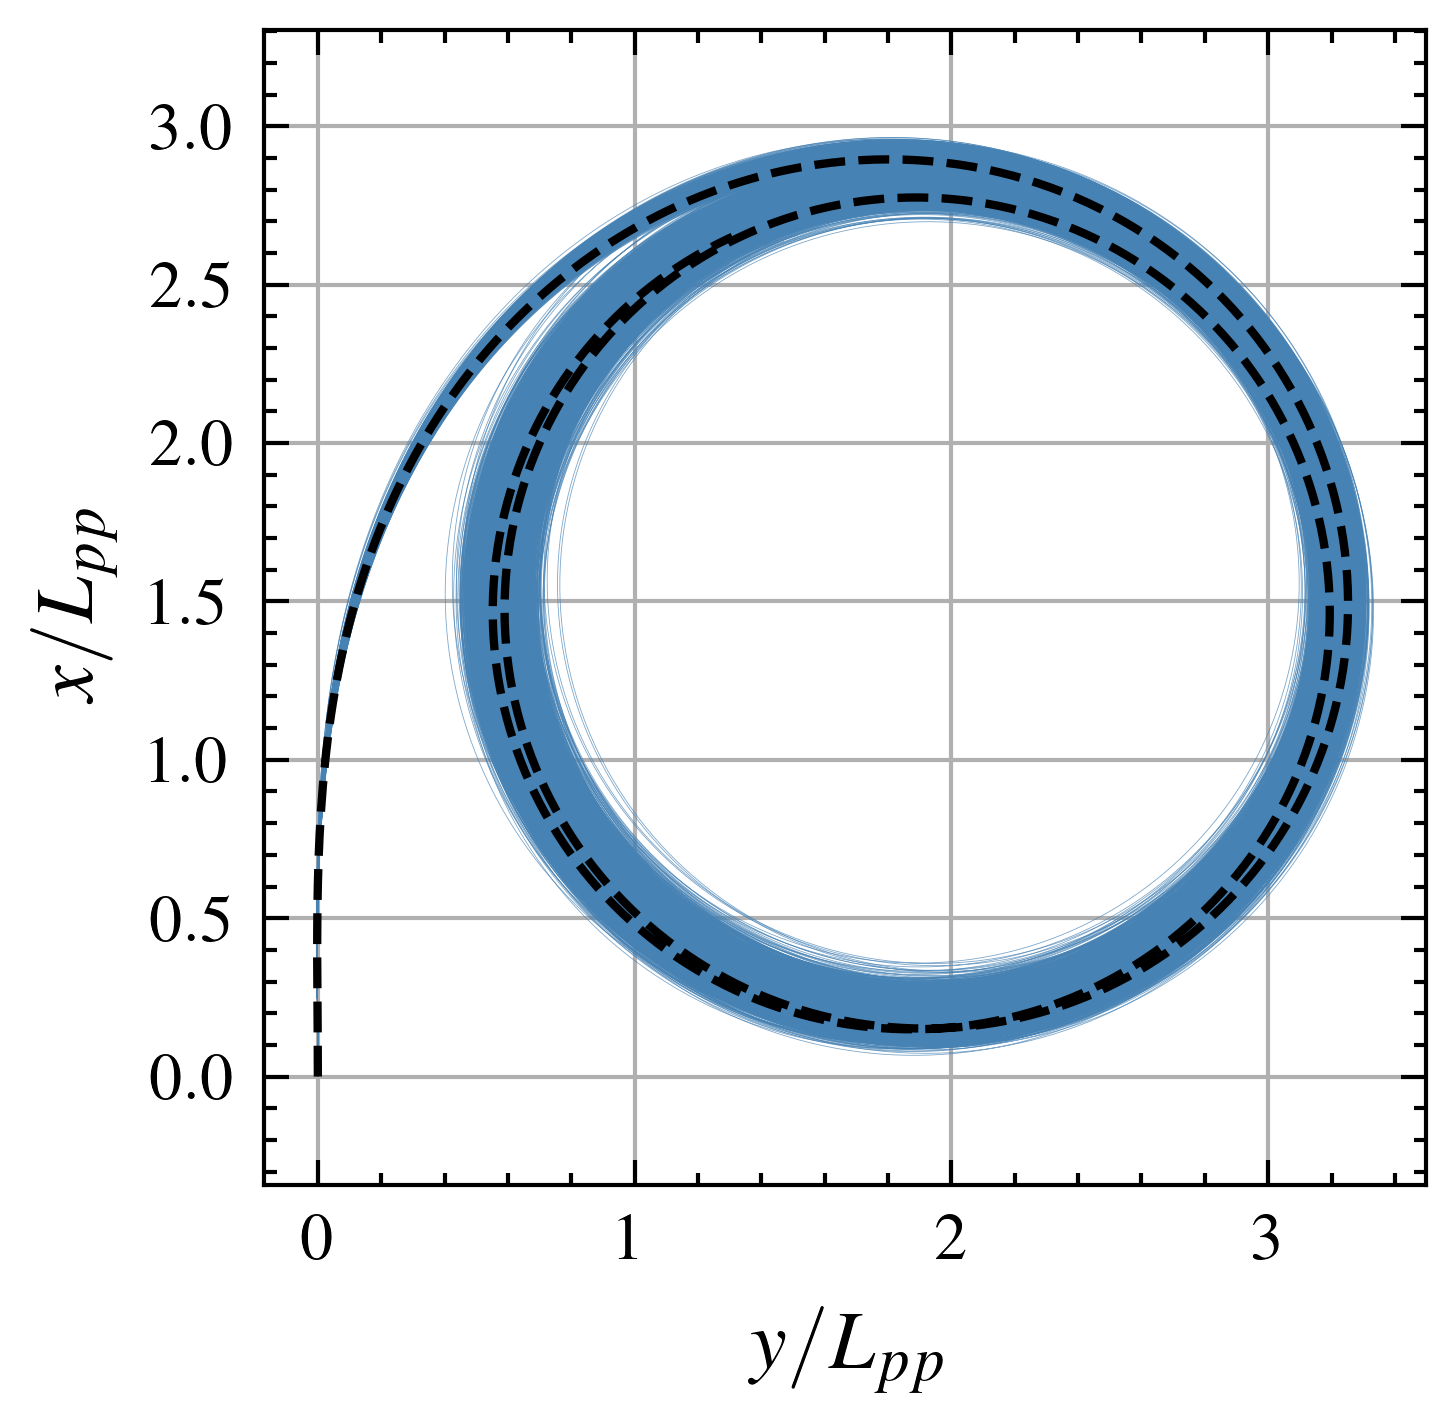

In [5]:
plt.style.use(["science", "ieee"])

fig = plt.figure(figsize=(2.5, 2.5))
ax = fig.add_subplot(1, 1, 1)

# for i in random_indices
for i in num1:num2
    mmg_results_df = results.data[i]
    ax.plot(mmg_results_df.y/L_pp, mmg_results_df.x/L_pp, "-", c="steelblue", alpha=0.7, linewidth=0.1)
end
ax.plot(y/L_pp, x/L_pp, "--", label="observation", c="k", alpha=1.0, linewidth=1.0)
ax.set_ylabel(L"x/L_{pp}", fontsize=10)
ax.set_xlabel(L"y/L_{pp}", fontsize=10)
# ax.legend(frameon=true, loc="lower right", fontsize=8)
ax.axis("equal")
# ax.set_xlim(-0.5, 7.5)
# ax.set_ylim(-2, 6)

ax.grid()
display(fig)

In [6]:
random_indices = sort(StatsBase.sample(num1:num2, 300; replace=false))
random_indices


300-element Vector{Int64}:
   11
   58
   64
   73
   79
   89
   91
   95
   96
  120
    ⋮
 3896
 3899
 3901
 3914
 3920
 3926
 3930
 3934
 3960

In [7]:
for idx in random_indices
    println(idx)
end

11
58
64
73
79
89
91
95
96
120
129
144
154
157
168
201
208
210
215
229
245
274
281
297
303
304
311
314
320
327
367
378
390
414
452
457
467
476
484
491
552
555
572
588
597
603
613
625
653
703
704
717
728
730
747
764
783
851
855
859
868
869
901
928
933
938
947
954
965
971
972
973
984
994
1014
1023
1029
1032
1035
1052
1055
1058
1086
1094
1105
1106
1110
1124
1137
1157
1162
1176
1219
1261
1265
1284
1294
1320
1337
1338
1345
1348
1369
1393
1397
1404
1408
1412
1413
1426
1458
1469
1486
1489
1513
1514
1518
1520
1539
1575
1584
1601
1629
1640
1641
1651
1660
1669
1681
1691
1692
1720
1722
1751
1790
1793
1796
1822
1862
1875
1884
1889
1901
1904
1905
1917
1925
1926
1929
1937
1939
1970
1975
1977
1979
2009
2012
2016
2032
2047
2052
2065
2066
2079
2088
2098
2110
2114
2119
2132
2149
2325
2327
2368
2369
2386
2410
2423
2426
2436
2440
2447
2467
2471
2472
2482
2483
2492
2503
2518
2541
2547
2563
2571
2616
2617
2618
2631
2637
2646
2663
2686
2693
2717
2732
2746
2748
2778
2779
2783
2799
2804
2822
2823
2847
2886
290